1.构建数据集

In [77]:
import math
import copy
import torch


def make_moons(n_samples=1000, shuffle=True,noise=None):
    n_samples_out = n_samples//2
    n_samples_in = n_samples - n_samples_out
    #生成两个类别的数据
    outer_circ_x = torch.cos(torch.linspace(0, math.pi, n_samples_out))
    outer_circ_y = torch.sin(torch.linspace(0, math.pi, n_samples_out))
    
    inner_circ_x = 1- torch.cos(torch.linspace(0, math.pi, n_samples_in))
    inner_circ_y = 0.5- torch.sin(torch.linspace(0, math.pi, n_samples_in))
    
    print('outer_circ_x.shape:',outer_circ_x.shape,'outer_circ_y.shape:',outer_circ_y.shape)
    print('outer_circ_x',outer_circ_x[:10])
    print('inner_circ_x.shape:',inner_circ_x.shape,'inner_circ_y.shape:',inner_circ_y.shape)
    print('inner_circ_x',inner_circ_x[:10])
    # 所有数据拼装
    concat_x = torch.cat([outer_circ_x, inner_circ_x])
    print('concat_x',concat_x.shape,'concat_x',concat_x[:10])
    concat_y = torch.cat([outer_circ_y, inner_circ_y])
    # 生成y标签
    X = torch.stack([concat_x, concat_y], dim=1)
    print(X.shape)
    y = torch.cat([torch.zeros(n_samples_out), torch.ones(n_samples_in)]).long()
    
    #样本打乱
    if shuffle:
        perm = torch.randperm(n_samples)
        X, y = X[perm], y[perm]
    
    if noise is not None:
        X += torch.randn(X.shape)*noise
        
    print('X',X[:5])
    print('y',y[:5])
    return X, y
        

outer_circ_x.shape: torch.Size([500]) outer_circ_y.shape: torch.Size([500])
outer_circ_x tensor([1.0000, 1.0000, 0.9999, 0.9998, 0.9997, 0.9995, 0.9993, 0.9990, 0.9987,
        0.9984])
inner_circ_x.shape: torch.Size([500]) inner_circ_y.shape: torch.Size([500])
inner_circ_x tensor([0.0000e+00, 1.9789e-05, 7.9274e-05, 1.7834e-04, 3.1710e-04, 4.9543e-04,
        7.1341e-04, 9.7096e-04, 1.2681e-03, 1.6049e-03])
concat_x torch.Size([1000]) concat_x tensor([1.0000, 1.0000, 0.9999, 0.9998, 0.9997, 0.9995, 0.9993, 0.9990, 0.9987,
        0.9984])
torch.Size([1000, 2])
X tensor([[ 1.4026,  0.3708],
        [-0.3160,  0.5364],
        [ 1.1427, -0.4455],
        [ 0.2160, -0.8949],
        [-0.1159,  0.7622]])
y tensor([1, 0, 1, 1, 1])
outer_circ_x.shape: torch.Size([500]) outer_circ_y.shape: torch.Size([500])
outer_circ_x tensor([1.0000, 1.0000, 0.9999, 0.9998, 0.9997, 0.9995, 0.9993, 0.9990, 0.9987,
        0.9984])
inner_circ_x.shape: torch.Size([500]) inner_circ_y.shape: torch.Size([500])
i

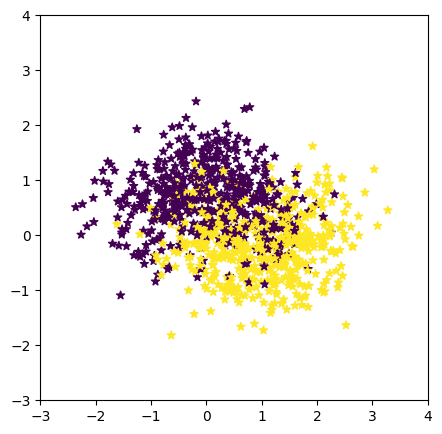

In [78]:
n_samples = 1000
X, y = make_moons(n_samples=n_samples,shuffle=True,noise=0.5)
make_moons(n_samples=1000)
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.scatter(x=X[:,0].tolist(),y=X[:,1].tolist(),marker='*',c=y.tolist())
plt.xlim(-3,4)
plt.ylim(-3,4)
plt.savefig('linear-dataset-vis.pdf')
plt.show()


拆分训练集、验证集和测试集

In [79]:
num_train = 640
num_dev = 160
num_test = 200
X_train,y_train = X[:num_train],y[:num_train]
X_dev,y_dev = X[num_train:num_train+num_dev],y[num_train:num_train+num_dev]
X_test,y_test = X[num_train+num_dev:],y[num_train+num_dev:]

y_train = y_train.reshape([-1,1])
y_dev = y_dev.reshape([-1,1])
y_test = y_test.reshape([-1,1])

print(X_train.shape,y_train.shape)
print(X_train[:5],y_train[:5])
print(X_dev.shape,y_dev.shape)
print(X_test.shape,y_test.shape)


torch.Size([640, 2]) torch.Size([640, 1])
tensor([[ 1.4026,  0.3708],
        [-0.3160,  0.5364],
        [ 1.1427, -0.4455],
        [ 0.2160, -0.8949],
        [-0.1159,  0.7622]]) tensor([[1],
        [0],
        [1],
        [1],
        [1]])
torch.Size([160, 2]) torch.Size([160, 1])
torch.Size([200, 2]) torch.Size([200, 1])


定义logistic函数模型

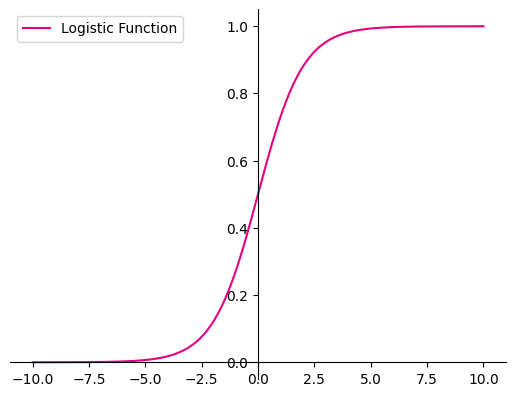

In [80]:
def logistic(x):
    return 1/(1+torch.exp(-x))

x = torch.linspace(-10,10,10000)
plt.figure()
plt.plot(x.tolist(),logistic(x).tolist(),color="#e4007f", label="Logistic Function")
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.spines['left'].set_position(('data',0))
ax.spines['bottom'].set_position(('data',0))

plt.legend()
plt.savefig('linear-logistic.pdf')
plt.show()

logistic回归算子

In [153]:
from nndl_chap3 import op3
class model_LR(op3.Op):
   def __init__(self, input_dim):
      super(model_LR, self).__init__(input_dim)
      self.params = {}
        #将线性层的权重参数初始化为0
      self.params['w'] = torch.zeros(input_dim,1)
        #将线性层的偏置参数初始化为0
      self.params['b'] = torch.zeros(1)
        #存放参数的梯度
      self.grads = {}
      self.X = None
      self.outputs = None
        
   def __call__(self, inputs):
        return self.forward(inputs)
    
   def forward(self,inputs):
       self.X = inputs
       '''
       输入：
         - inputs : shape=[N,D],N是样本数量，D是特征维度
       输出：
         - outputs：预测标签为1的概率，shape = [N,1]
       :param inputs: 
       :return: 
       ''' 
       # 线性计算
       score = torch.matmul(inputs,self.params['w']+self.params['b'])
       self.outputs = logistic(score)
       return self.outputs
    
   def backward(self, labels):
        '''
        输入： 
           --labels: 真实标签,shape = [N,1]
        '''
        N = labels.shape[0]
        #print('labels is:',labels)
        #print('self.outputs',self.outputs)
       

        self.grads['w'] = -1 / N * torch.matmul(self.X.t(),(labels - self.outputs))
        self.grads['b'] = -1 / N * torch.sum(labels - self.outputs)

测试一下，随机生成3条长度为4的数据数据如logistic回归模型，观察输出结果

In [154]:


# 设置随机种子，保持每次运行结果一致
torch.manual_seed(0)
# 随机生成3条长度为4的数据
inputs = torch.randn(3,4)
print('inputs is:',inputs)
# 实例化模型
model = model_LR(4)

outputs = model(inputs=inputs)

print('output is:',outputs)

inputs is: tensor([[ 1.5410, -0.2934, -2.1788,  0.5684],
        [-1.0845, -1.3986,  0.4033,  0.8380],
        [-0.7193, -0.4033, -0.5966,  0.1820]])
output is: tensor([[0.5000],
        [0.5000],
        [0.5000]])


定义损失函数

In [155]:
class BinaryCrossEntropyLoss(op3.Op):
    def __init__(self):
        self.predicts = None
        self.labels = None
        self.num = None
         
    def __call__(self, predicts, labels):
        return self.forward(predicts, labels)
    
    def forward(self, predicts, labels):
        '''
        输入：
           --predicts：预测值，shape=[N,1],N为样本数量
           --labels：真实标签，shape=[N,1]
        输出：
          --损失值：shape = [1]
        '''
        self.predicts = predicts.float() 
        self.labels = labels.float() 
        self.num = self.predicts.shape[0]
        loss = -1.0/self.num*(torch.matmul(self.labels.t(),torch.log(self.predicts))+torch.matmul((1-self.labels.t()),torch.log(1-self.predicts)))
        loss = torch.squeeze(loss,1)
        return loss
    
labels = torch.zeros(3,1)
bce_loss = BinaryCrossEntropyLoss()
print(bce_loss(outputs,labels))

tensor([0.6931])


模型优化，采用梯度下降法，通常将偏导数的计算过程定义在logistic回归算子的backward函数中

In [156]:
from abc import abstractclassmethod

#优化器基类
class Optimizer(object):
    def __init__(self,init_lr,model):
        '''
        优化器类初始化
        '''
        # 初始化学习率，用于参数更新的计算
        self.init_lr = init_lr
        # 指定优化器需要优化的模型
        self.model = model
    
    def step(self):
        '''
        参数更新
        '''
        pass

实现一个梯度下降法的优化器函数SimpleBatchGD来执行参数更新过程

In [157]:
class SimpleBatchGD(Optimizer):
    def __init__(self,init_lr,model):
        super(SimpleBatchGD, self).__init__(init_lr=init_lr,model=model)
        
    def step(self):
        # 参数更新
        # 便利所有参数，按照公式进行更新
        if isinstance(self.model.params,dict):
            for key in self.model.params.keys():
                self.model.params[key] = self.model.params[key]-self.init_lr*self.model.grads[key]

定义评价指标

In [158]:
def accuracy(preds,labels):
    '''
    输入：
        --preds:预测值，二分类时，shape = [N,1],N为样本数量，多分类时，shape = [N,C],C为类别数量
        --labels：真实标签，shape = [N,1]
    输出：
        -- 准确率：shape=[1]
    '''
    # 判断是二分类还是多分类任务，pred.shape[1]=1时为二分类任务，pred.shape>1时是多分类任务
    if preds.shape[1] == 1:
        preds = (preds >=0.5).to(dtype=torch.float32)
    else:
        preds = torch.argmax(preds,dim=1).to(dtype=torch.int32)

    # 计算准确率
    corrrect = (preds == labels.squeeze()).to(dtype=torch.float32)
    acc = torch.mean(corrrect)
    return acc
preds = torch.tensor([[0.],[1.],[1.],[0.]])
labels = torch.tensor([[1.],[1.],[0.],[0.]])
print("accuracy is:", accuracy(preds, labels).item())

accuracy is: 0.5


完善Runner类

In [159]:
class RunnerV2(object):
    def __init__(self,model,optimizer,metric,loss_fn):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metric = metric
        # 记录训练过程中的评价指标变化情况
        self.train_scores = []
        self.dev_scores = []
        # 记录训练过程中的损失函数变化情况
        self.train_loss = []
        self.dev_loss = []
    def train(self,train_set,dev_set,**kwargs):
        # 传入训练轮数，如果没有传入值则默认为0
        num_epochs = kwargs.get('num_epochs',0)
        # 传入log打印频率，如果没有传入值则默认为100
        log_epochs = kwargs.get('log_epochs',100)
        # 传入模型保存路径，如果没有就传入值则默认为“best_model.pdparams”
        save_path = kwargs.get('save_path','best_model.pdparams')
        # 传入梯度打印函数，如果没有传入值则默认为None
        print_grads = kwargs.get('print_grads',None)
        # 记录全局最优指标
        best_score = 0
        # 进行num_epochs轮训练
        for epoch in range(num_epochs):
            X,y = train_set
            #获取模型预测
            logits = self.model(X)
            # print(logits,y)
            #计算交叉熵损失
            trn_loss = self.loss_fn(logits,y).item()
            self.train_loss.append(trn_loss)
            # 计算评价指标
            trn_score = self.metric(logits,y).item()
            self.train_scores.append(trn_score)
            # 计算参数梯度
            self.model.backward(y)
            if print_grads is not None:
                print_grads(self.model)#打印每一层的梯度
            # 更新模型参数
            self.optimizer.step()
            dev_score,dev_loss = self.evaluate(dev_set)
            #如果当前指标为最优指标，保存该模型
            if dev_score > best_score:
                self.save_model(save_path)
                print(f'best accuracy performence has been updated:{best_score:.5f} --> {dev_score:.5f}')
                best_score = dev_score
            if epoch % log_epochs == 0:
                print(f'[Train] epoch: {epoch},loss:{trn_loss},score:{trn_score}')
                print(f'[Dev] epoch:{epoch},loss:{dev_loss},score:{dev_score}')
    def evaluate(self,data_set):
        X,y = data_set
        #计算模型输出
        logits = self.model(X)
        #计算损失函数
        loss = self.loss_fn(logits,y).item()
        self.dev_loss.append(loss)
        #计算评价指标
        score = self.metric(logits,y).item()
        self.dev_scores.append(score)
        return score,loss
    def predict(self,X):
        return self.model(X)
    
    def save_model(self,sava_path):
        torch.save(self.model.params,sava_path)
    def load_model(self,model_path):
        self.model.params = torch.load(model_path)

模型训练

In [161]:
#固定随机种子，使每次运行结果保持一直
torch.manual_seed(102)

#特征维度
input_dim = 2
# 学习率
lr = 0.1
#实例化模型
model = model_LR(input_dim=input_dim)
#指定优化器
optimizer = SimpleBatchGD(init_lr=lr,model=model)
#指定损失函数
loss_fn = BinaryCrossEntropyLoss()
#指定评价方式
metric = accuracy

# 实例化RunnerV2类，并传入训练配置
runner = RunnerV2(model=model,optimizer=optimizer,metric=metric,loss_fn=loss_fn)
#训练模型
runner.train([X_train,y_train],[X_dev,y_dev],num_epochs = 500,log_epochs = 50,save_path='best_model.pdparams')


best accuracy performence has been updated:0.00000 --> 0.50125
[Train] epoch: 0,loss:0.693146824836731,score:0.4765625
[Dev] epoch:0,loss:0.6838022470474243,score:0.5012500286102295
[Train] epoch: 50,loss:0.4824790954589844,score:0.49956053495407104
[Dev] epoch:50,loss:0.5015119910240173,score:0.5006250143051147
[Train] epoch: 100,loss:0.4422217905521393,score:0.5
[Dev] epoch:100,loss:0.46420955657958984,score:0.5006250143051147
[Train] epoch: 150,loss:0.42877253890037537,score:0.500439465045929
[Dev] epoch:150,loss:0.4509700834751129,score:0.5006250143051147
[Train] epoch: 200,loss:0.4232335686683655,score:0.5005859136581421
[Dev] epoch:200,loss:0.44511541724205017,score:0.5006250143051147
[Train] epoch: 250,loss:0.4207240045070648,score:0.500732421875
[Dev] epoch:250,loss:0.44220587611198425,score:0.5006250143051147
[Train] epoch: 300,loss:0.419543594121933,score:0.500732421875
[Dev] epoch:300,loss:0.4406529366970062,score:0.5004687309265137
[Train] epoch: 350,loss:0.4189925789833069

可观察训练集与验证集的准确率和损失变化情况

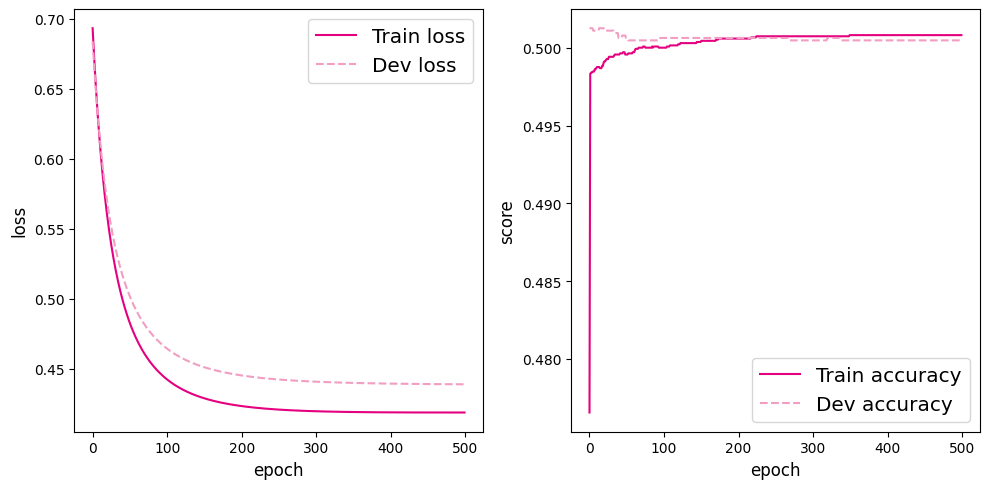

In [162]:
# 可视化观察训练集与验证集的指标变化情况
def plot(runner,fig_name):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    epochs = [i for i in range(len(runner.train_scores))]
    # 绘制训练损失变化曲线
    plt.plot(epochs, runner.train_loss, color='#e4007f', label="Train loss")
    # 绘制评价损失变化曲线
    plt.plot(epochs, runner.dev_loss, color='#f19ec2', linestyle='--', label="Dev loss")
    # 绘制坐标轴和图例
    plt.ylabel("loss", fontsize='large')
    plt.xlabel("epoch", fontsize='large')
    plt.legend(loc='upper right', fontsize='x-large')
    plt.subplot(1,2,2)
    # 绘制训练准确率变化曲线
    plt.plot(epochs, runner.train_scores, color='#e4007f', label="Train accuracy")
    # 绘制评价准确率变化曲线
    plt.plot(epochs, runner.dev_scores, color='#f19ec2', linestyle='--', label="Dev accuracy")
    # 绘制坐标轴和图例
    plt.ylabel("score", fontsize='large')
    plt.xlabel("epoch", fontsize='large')
    plt.legend(loc='lower right', fontsize='x-large')
    plt.tight_layout()
    plt.savefig(fig_name)
    plt.show()

plot(runner,fig_name='linear-acc.pdf')

模型评价

In [163]:
score, loss = runner.evaluate([X_test, y_test])
print("[Test] score/loss: {:.4f}/{:.4f}".format(score, loss))

[Test] score/loss: 0.5071/0.4077


可视化观察拟合的决策边界 Wx+b=0

In [164]:
def decision_boundary(w, b, x1):
    w1, w2 = w
    x2 = (- w1 * x1 - b) / w2
    return x2

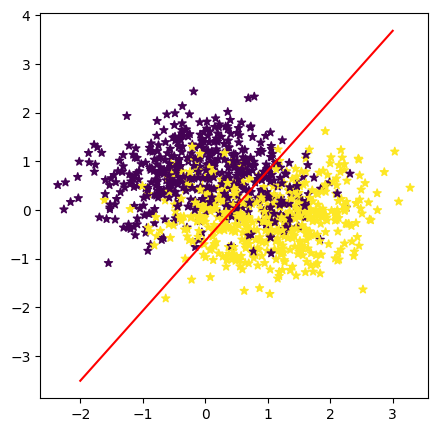

In [165]:
plt.figure(figsize=(5,5))
# 绘制原始数据
plt.scatter(X[:, 0].tolist(), X[:, 1].tolist(), marker='*', c=y.tolist())

w = model.params['w']
b = model.params['b']
x1 = torch.linspace(-2, 3, 1000)
x2 = decision_boundary(w, b, x1)
# 绘制决策边界
plt.plot(x1.tolist(), x2.tolist(), color="red")
plt.show()